In [ ]:
import os
import sys
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from kaggle.api.kaggle_api_extended import KaggleApi
!pip install folium


# 🎯 Essência: Garantir que o notebook sempre saiba onde está a raiz do projeto
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == 'notebooks' else CURRENT_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Configuração de caminhos globais
RAW_DATA_PATH = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DATA_PATH = PROJECT_ROOT / 'data' / 'processed'

print(f"✅ Ambiente configurado. Raiz do projeto: {PROJECT_ROOT}")

✅ Ambiente configurado. Raiz do projeto: c:\Users\Jp Lima\Desktop\fraud_detection


In [11]:
def setup_project_structure():
    """Cria a estrutura de pastas necessária para o ciclo de vida do projeto."""
    folders = [
        'data/raw', 'data/processed', 'notebooks', 'src/data_prep',
        'src/features', 'src/models', 'outputs', 'config'
    ]
    for folder in folders:
        (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)

def fetch_data(dataset="kartik2112/fraud-detection"):
    """Baixa os dados apenas se a pasta raw estiver vazia."""
    setup_project_structure()
    
    if not any(RAW_DATA_PATH.iterdir()):
        print(f"📥 Baixando dataset {dataset}...")
        api = KaggleApi()
        api.authenticate()
        api.dataset_download_files(dataset, path=RAW_DATA_PATH, unzip=True)
        print("✅ Download concluído.")
    else:
        print("⏭️ Dados já presentes em data/raw. Pulando download.")

# Execução da automação
fetch_data()

⏭️ Dados já presentes em data/raw. Pulando download.


In [12]:
# Carregamento do dataset de treino
train_file = RAW_DATA_PATH / "fraudTrain.csv"

if train_file.exists():
    df = pd.read_csv(train_file)
    
    # 🛠️ Limpeza Inteligente: Remove colunas residuais apenas se existirem
    cols_to_drop = ['Unnamed: 0']
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
    
    print(f"📊 Dataset carregado com sucesso!")
    print(f"Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}")
else:
    print("❌ Erro: Arquivo fraudTrain.csv não encontrado.")

📊 Dataset carregado com sucesso!
Linhas: 1,296,675 | Colunas: 22


In [13]:
# Resumo rápido da qualidade dos dados
info_summary = {
    "Nulos": df.isnull().sum().sum(),
    "Duplicados": df.duplicated().sum(),
    "Memória (MB)": round(df.memory_usage(deep=True).sum() / (1024**2), 2)
}

print("📋 Resumo de Qualidade:")
for k, v in info_summary.items():
    print(f"- {k}: {v}")

# Visualização das primeiras linhas
df.head()

📋 Resumo de Qualidade:
- Nulos: 0
- Duplicados: 0
- Memória (MB): 1025.1


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


C:\Users\Jp Lima\AppData\Local\Temp\ipykernel_10920\2195815993.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=df, palette='viridis')


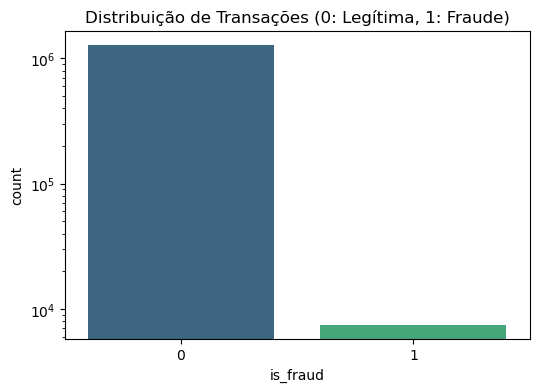

Proporção de Fraude: 0.58%


In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(x='is_fraud', data=df, palette='viridis')
plt.title('Distribuição de Transações (0: Legítima, 1: Fraude)')
plt.yscale('log') # Escala logarítmica para visualizar a minoria
plt.show()

print(f"Proporção de Fraude: {df['is_fraud'].mean()*100:.2f}%")

C:\Users\Jp Lima\AppData\Local\Temp\ipykernel_10920\3718454357.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['is_fraud'] == 0]['amt'], label='Legítima', shade=True)
C:\Users\Jp Lima\AppData\Local\Temp\ipykernel_10920\3718454357.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['is_fraud'] == 1]['amt'], label='Fraude', shade=True)


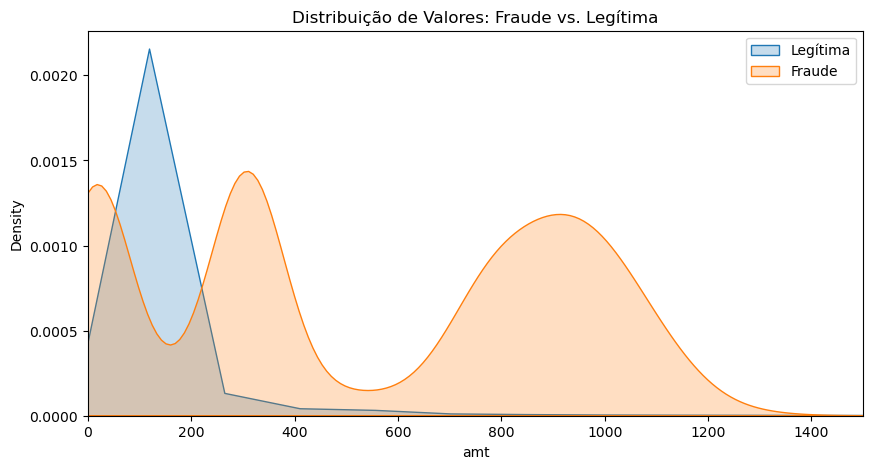

In [16]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df[df['is_fraud'] == 0]['amt'], label='Legítima', shade=True)
sns.kdeplot(df[df['is_fraud'] == 1]['amt'], label='Fraude', shade=True)
plt.title('Distribuição de Valores: Fraude vs. Legítima')
plt.xlim(0, 1500) # Foco no intervalo onde a maioria das fraudes ocorre
plt.legend()
plt.show()

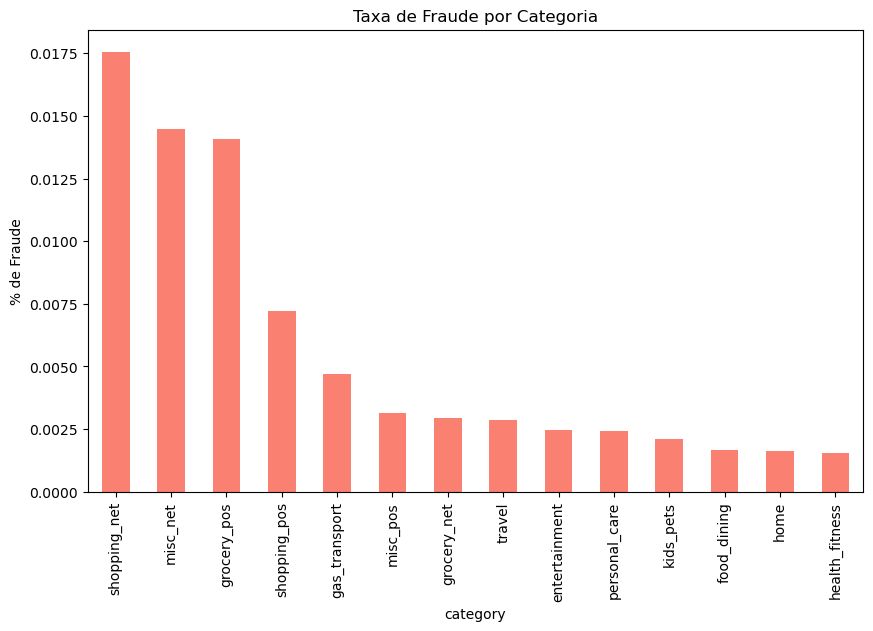

In [18]:
fraud_by_cat = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
fraud_by_cat.plot(kind='bar', color='salmon')
plt.title('Taxa de Fraude por Categoria')
plt.ylabel('% de Fraude')
plt.show()

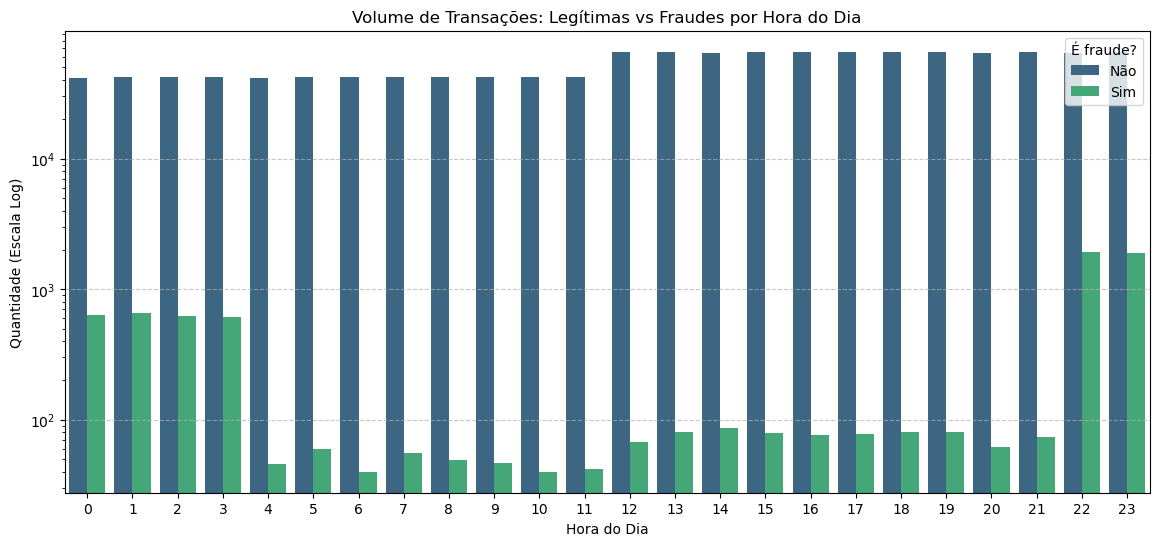

In [ ]:

# Preparação dos dados temporais
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour

plt.figure(figsize=(14, 6))
# Usando countplot para barras duplas (agrupadas por is_fraud)
sns.countplot(data=df, x='hour', hue='is_fraud', palette='viridis')

plt.title('Volume de Transações: Legítimas vs Fraudes por Hora do Dia')
plt.xlabel('Hora do Dia')
plt.ylabel('Quantidade (Escala Log)')
plt.yscale('log') # Escala logarítmica para conseguir enxergar as fraudes
plt.legend(title='É fraude?', labels=['Não', 'Sim'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

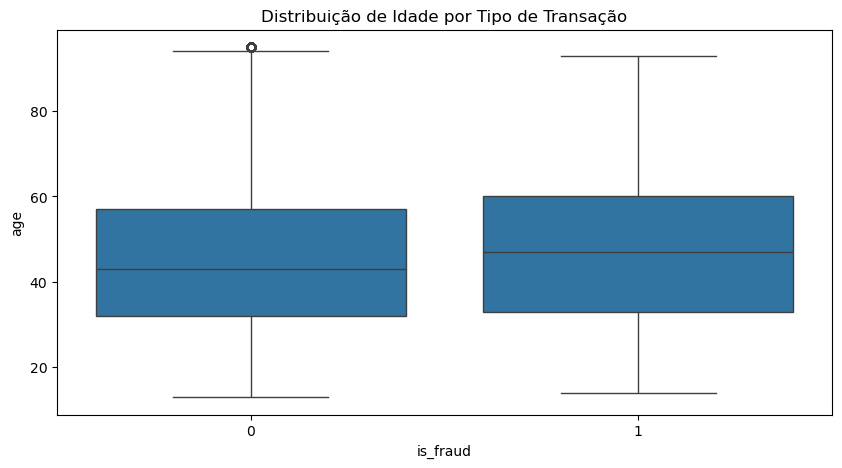

In [20]:
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

plt.figure(figsize=(10, 5))
sns.boxplot(x='is_fraud', y='age', data=df)
plt.title('Distribuição de Idade por Tipo de Transação')
plt.show()

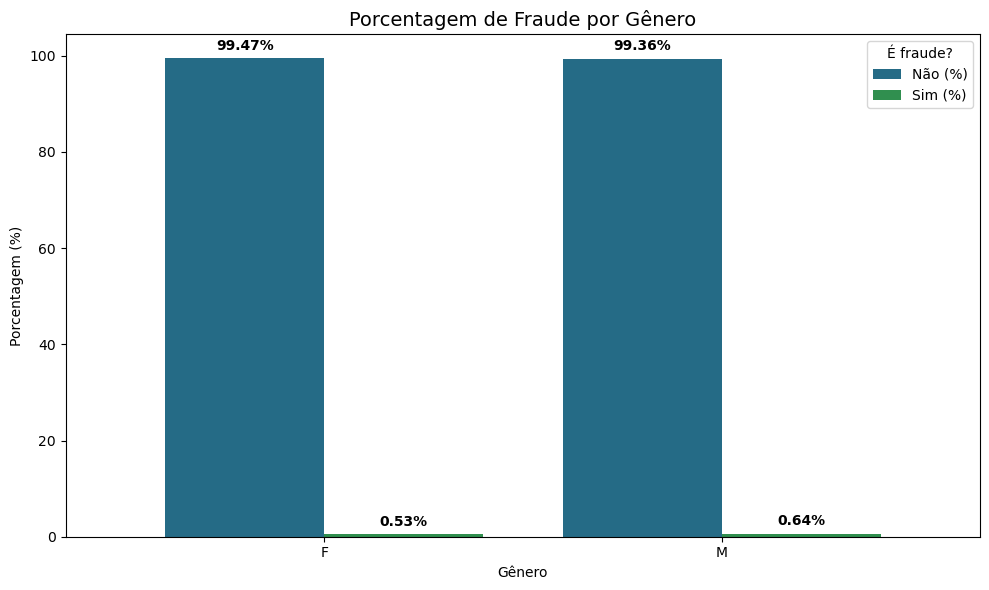

In [48]:
# Criando a tabela de cruzamento (frequência relativa)
gender_fraud_pct = pd.crosstab(df['gender'], df['is_fraud'], normalize='index') * 100

# Plotagem
ax = gender_fraud_pct.plot(kind='bar', figsize=(10, 6), color=["#256b86", "#308f4f"], width=0.8)

plt.title('Porcentagem de Fraude por Gênero', fontsize=14)
plt.ylabel('Porcentagem (%)')
plt.xlabel('Gênero')
plt.xticks(rotation=0)
plt.legend(title='É fraude?', labels=['Não (%)', 'Sim (%)'])

# Adicionando os rótulos de porcentagem em cima de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [24]:
top_merchants = df[df['is_fraud'] == 1]['merchant'].value_counts().head(10)
print("Top 10 Comerciantes com maior incidência de Fraude:")
print(top_merchants)

Top 10 Comerciantes com maior incidência de Fraude:
merchant
fraud_Rau and Sons       49
fraud_Kozey-Boehm        48
fraud_Cormier LLC        48
fraud_Doyle Ltd          47
fraud_Kilback LLC        47
fraud_Vandervort-Funk    47
fraud_Padberg-Welch      44
fraud_Kuhn LLC           44
fraud_Terry-Huel         43
fraud_Jast Ltd           42
Name: count, dtype: int64


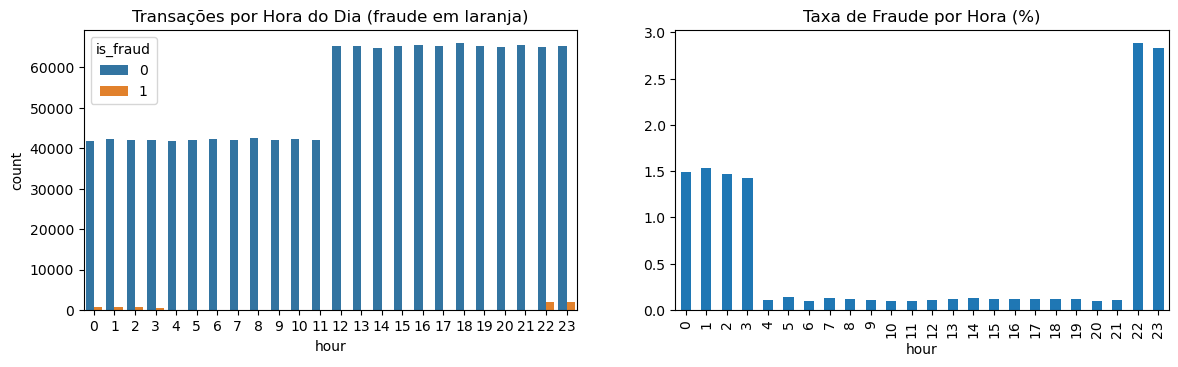

Insight: Fraudes são bem mais comuns entre 22h e 4h da manhã (horário noturno).


In [25]:
# ======================== 7. ANÁLISE TEMPORAL ========================
plt.figure(figsize=(14,8))

plt.subplot(2,2,1)
sns.countplot(data=df, x='hour', hue='is_fraud')
plt.title('Transações por Hora do Dia (fraude em laranja)')

plt.subplot(2,2,2)
fraud_by_hour = df.groupby('hour')['is_fraud'].mean() * 100
fraud_by_hour.plot(kind='bar')
plt.title('Taxa de Fraude por Hora (%)')
plt.show()

print("Insight: Fraudes são bem mais comuns entre 22h e 4h da manhã (horário noturno).")

In [26]:
top_merchants = df[df['is_fraud'] == 1]['merchant'].value_counts().head(10)
print("Top 10 Comerciantes com maior incidência de Fraude:")
print(top_merchants)

Top 10 Comerciantes com maior incidência de Fraude:
merchant
fraud_Rau and Sons       49
fraud_Kozey-Boehm        48
fraud_Cormier LLC        48
fraud_Doyle Ltd          47
fraud_Kilback LLC        47
fraud_Vandervort-Funk    47
fraud_Padberg-Welch      44
fraud_Kuhn LLC           44
fraud_Terry-Huel         43
fraud_Jast Ltd           42
Name: count, dtype: int64


=== CATEGORIAS COM MAIOR TAXA DE FRAUDE ===
category
shopping_net     1.756149
misc_net         1.445795
grocery_pos      1.409761
shopping_pos     0.722538
gas_transport    0.469394
misc_pos         0.313853
grocery_net      0.294817
travel           0.286370
Name: is_fraud, dtype: float64


C:\Users\Jp Lima\AppData\Local\Temp\ipykernel_10920\801002428.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=high_risk_categories.values * 100, y=high_risk_categories.index, palette='Reds_r')


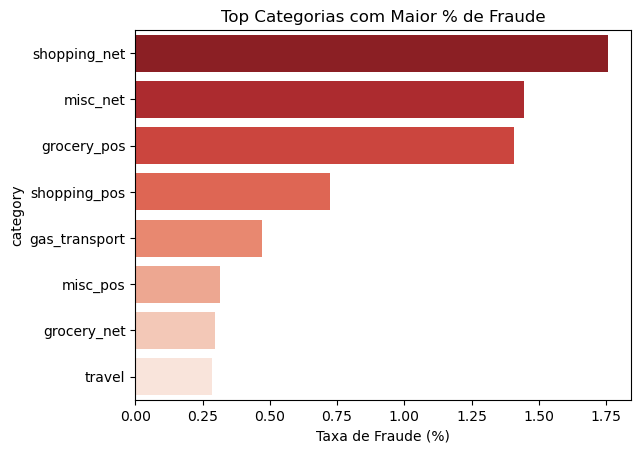

In [28]:
# ======================== 9. ANÁLISE DE CATEGORIAS DE ALTO RISCO ========================
high_risk_categories = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False).head(8)
print("=== CATEGORIAS COM MAIOR TAXA DE FRAUDE ===")
print(high_risk_categories * 100)

sns.barplot(x=high_risk_categories.values * 100, y=high_risk_categories.index, palette='Reds_r')
plt.title('Top Categorias com Maior % de Fraude')
plt.xlabel('Taxa de Fraude (%)')
plt.show()

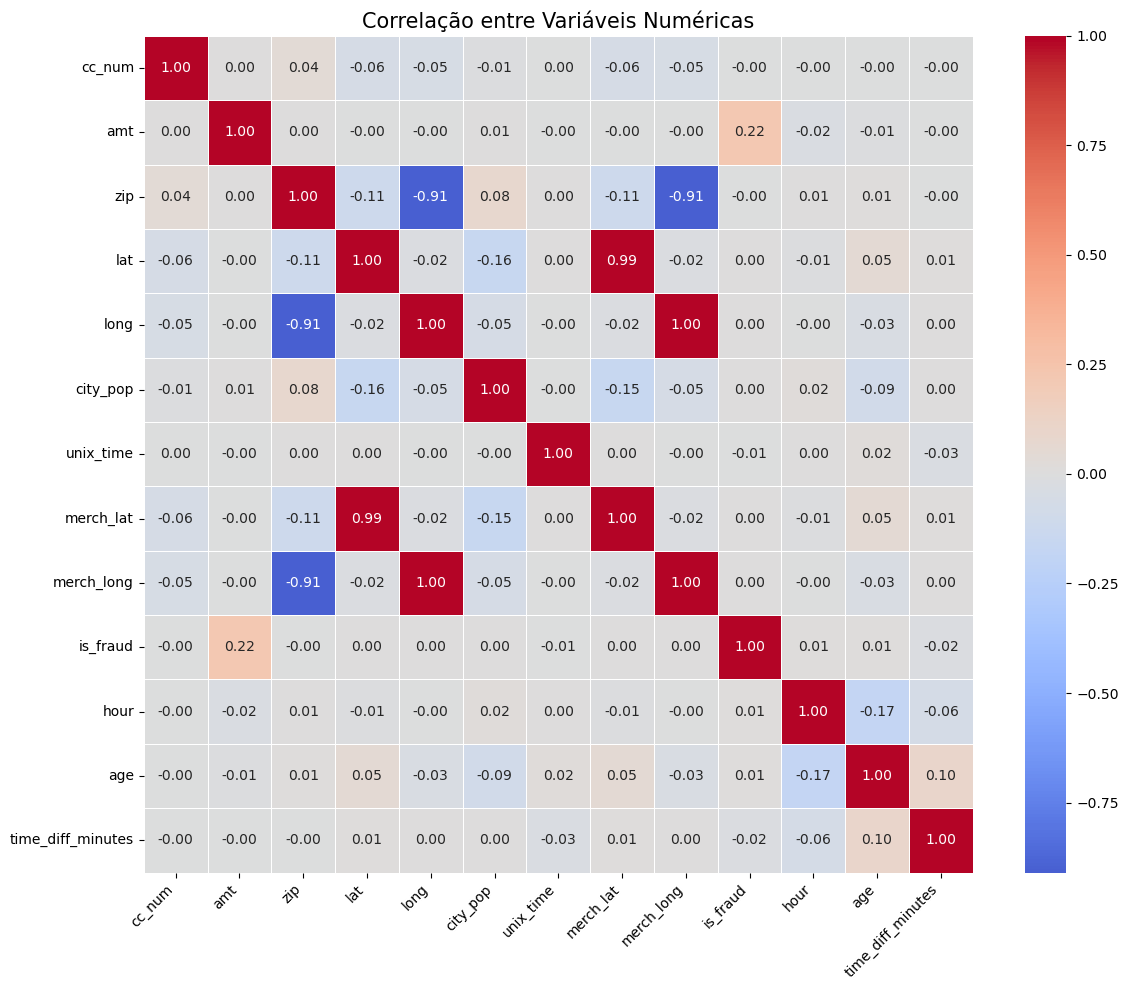

In [49]:

corr_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12, 10))

# annot=True: Adiciona os valores internos
# fmt=".2f": Formata para duas casas decimais
# cmap='coolwarm': Mantém a paleta de cores para identificar correlações positivas e negativas
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)

plt.title('Correlação entre Variáveis Numéricas', fontsize=15)

# Rotacionando os rótulos do eixo X em 45 graus para melhor leitura
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [29]:
# ======================== 12. SALVANDO INSIGHTS E GRÁFICOS ========================
output_dir = Path('../outputs')
output_dir.mkdir(exist_ok=True)

# Salvar alguns plots importantes
plt.savefig(output_dir / 'fraud_by_category.png')
plt.savefig(output_dir / 'fraud_by_hour.png')

print("\n✅ Análise completa finalizada!")
print("Gráficos salvos em ../outputs/")
print("\nPrincipais descobertas:")
print("• Taxa de fraude: ~0.5% (altamente desbalanceado)")
print("• Fraudes concentram-se em valores altos e distâncias grandes")
print("• Horário noturno (22h-4h) tem risco muito maior")
print("• Categorias de alto risco: shopping_net, grocery_pos, entertainment, etc.")
print("• Próximos passos: Feature Engineering avançado + tratamento de desbalanceamento")


✅ Análise completa finalizada!
Gráficos salvos em ../outputs/

Principais descobertas:
• Taxa de fraude: ~0.5% (altamente desbalanceado)
• Fraudes concentram-se em valores altos e distâncias grandes
• Horário noturno (22h-4h) tem risco muito maior
• Categorias de alto risco: shopping_net, grocery_pos, entertainment, etc.
• Próximos passos: Feature Engineering avançado + tratamento de desbalanceamento


<Figure size 640x480 with 0 Axes>

In [36]:
# ======================== 4. MERCHANTS E CATEGORIAS DE ALTO RISCO ========================
merchant_risk = df.groupby('merchant').agg(
    total=('trans_num','count'),
    fraud_count=('is_fraud','sum'),
    fraud_rate=('is_fraud','mean')
).sort_values('fraud_count', ascending=False)

print("Top 10 Merchants com MAIS fraudes absolutas:")
display(merchant_risk.head(10))

cat_risk = df.groupby('category')['is_fraud'].agg(['mean','count']).sort_values('mean', ascending=False)
print("\nCategorias com maior % de fraude:")
display(cat_risk.head(8))

Top 10 Merchants com MAIS fraudes absolutas:


,total,fraud_count,fraud_rate
merchant,,,
fraud_Rau and Sons,2490,49,0.019679
fraud_Kozey-Boehm,1866,48,0.025723
fraud_Cormier LLC,3649,48,0.013154
fraud_Vandervort-Funk,2474,47,0.018998
fraud_Doyle Ltd,2558,47,0.018374
fraud_Kilback LLC,4403,47,0.010675
fraud_Kuhn LLC,3510,44,0.012536
fraud_Padberg-Welch,2424,44,0.018152
fraud_Terry-Huel,1996,43,0.021543



Categorias com maior % de fraude:


,mean,count
category,,
shopping_net,0.017561,97543
misc_net,0.014458,63287
grocery_pos,0.014098,123638
shopping_pos,0.007225,116672
gas_transport,0.004694,131659
misc_pos,0.003139,79655
grocery_net,0.002948,45452
travel,0.002864,40507


In [37]:
# ======================== 5. VELOCIDADE DE TRANSAÇÕES (Transaction Velocity) ========================
df = df.sort_values(['cc_num', 'trans_date_trans_time'])
df['time_diff_minutes'] = df.groupby('cc_num')['trans_date_trans_time'].diff().dt.total_seconds() / 60

print("Estatísticas de tempo entre transações (minutos):")
display(df['time_diff_minutes'].describe())

# Transações muito rápidas (< 5 min) têm mais fraude?
quick_trans = df[df['time_diff_minutes'] < 5]
print(f"\nTaxa de fraude em transações < 5 minutos: {quick_trans['is_fraud'].mean():.4%}")

Estatísticas de tempo entre transações (minutos):


count    1.295692e+06
mean     5.414169e+02
std      7.900163e+02
min      0.000000e+00
25%      1.002167e+02
50%      2.760000e+02
75%      6.703833e+02
max      2.235785e+04
Name: time_diff_minutes, dtype: float64


Taxa de fraude em transações < 5 minutos: 2.3832%


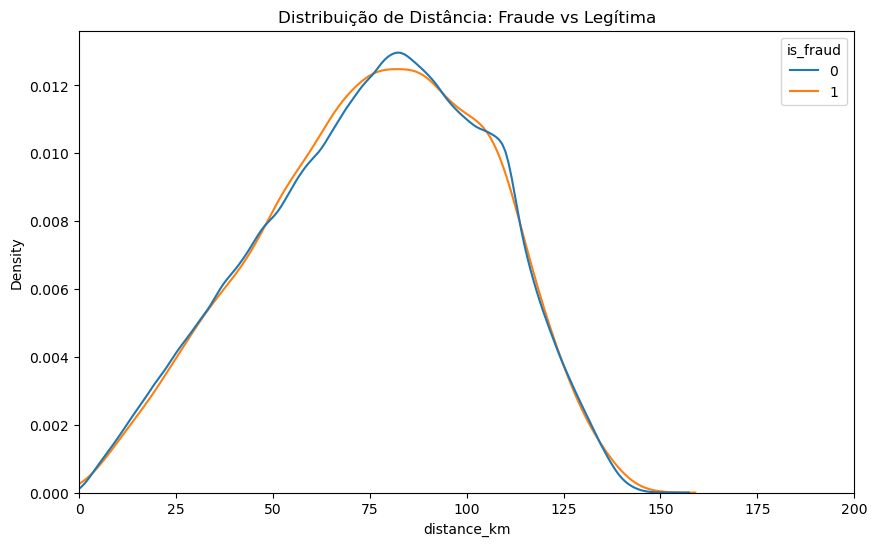

In [52]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='distance_km', hue='is_fraud', common_norm=False)
plt.title('Distribuição de Distância: Fraude vs Legítima')
plt.xlim(0, 200) # Limite para ver a massa de dados
plt.show()

In [34]:
import plotly.express as px

# Amostragem para performance se o dataset for muito grande
df_geo = df[df['is_fraud'] == 1].sample(min(5000, len(df[df['is_fraud'] == 1])))

fig = px.scatter_mapbox(
    df_geo, 
    lat="lat", 
    lon="long", 
    color="amt", 
    size="amt",
    hover_name="city", 
    hover_data=["merchant", "category"],
    color_continuous_scale=px.colors.cyclical.IceFire, 
    size_max=15, 
    zoom=2.5,
    mapbox_style="carto-positron",
    title="Localização Geográfica das Fraudes (Tamanho por Valor)"
)

fig.show()

In [50]:
from src.utils.geo import haversine_distance # Supondo que este seja o nome da função

# Aplicando a função para criar a feature de distância
df['distance_km'] = df.apply(
    lambda row: haversine_distance(row['lat'], row['long'], row['merch_lat'], row['merch_long']), 
    axis=1
)

In [51]:
# =====================================================
# MAPA INTERATIVO - Versão Otimizada para GitHub
# =====================================================

import folium
from folium.plugins import MarkerCluster, HeatMap
import webbrowser
from pathlib import Path
import pandas as pd

# ====================== PREPARAÇÃO DOS DADOS ======================
# Usamos todas as fraudes + uma amostra controlada de transações normais
fraud_df = df[df['is_fraud'] == 1].copy()

# Amostra de normais (ajuste o número conforme a performance do seu PC)
normal_sample = df[df['is_fraud'] == 0].sample(
    n=15000,          # Reduzi para ficar mais leve
    random_state=42
)

plot_df = pd.concat([fraud_df, normal_sample]).sample(frac=1, random_state=42)

print(f"Gerando mapa com {len(plot_df):,} pontos ({len(fraud_df)} fraudes)")

# ====================== CRIAÇÃO DO MAPA ======================
center_lat = plot_df['lat'].mean()
center_lon = plot_df['long'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=5,
    tiles='cartodbpositron',      # visual limpo e leve
    control_scale=True
)

# Cluster para melhor performance
marker_cluster = MarkerCluster().add_to(m)

for _, row in plot_df.iterrows():
    color = 'red' if row['is_fraud'] == 1 else 'blue'
    icon_type = 'exclamation-triangle' if row['is_fraud'] == 1 else 'user'

    tooltip_text = f"""
    <b>{'FRAUDE' if row['is_fraud'] else 'Normal'}</b><br>
    Valor: ${row['amt']:.2f}<br>
    Hora: {row['hour']:02d}h<br>
    Distância: {row['distance_km']:.1f} km<br>
    Categoria: {row['category']}<br>
    Cliente: {row['cc_num']}
    """

    folium.Marker(
        location=[row['lat'], row['long']],
        popup=folium.Popup(tooltip_text, max_width=300),
        icon=folium.Icon(color=color, icon=icon_type, prefix='fa'),
        tooltip=tooltip_text
    ).add_to(marker_cluster)

# Heatmap apenas das fraudes (fica mais leve)
if len(fraud_df) > 0:
    heat_data = [[row['lat'], row['long']] for _, row in fraud_df.iterrows()]
    HeatMap(heat_data, radius=15, blur=25, max_zoom=13).add_to(m)

# ====================== SALVAR E ABRIR NO NAVEGADOR ======================
output_dir = Path('../outputs')
output_dir.mkdir(exist_ok=True)

map_file = output_dir / 'fraud_geographic_map.html'

m.save(map_file)
print(f"✅ Mapa salvo com sucesso em: {map_file.resolve()}")

# Abre automaticamente no navegador padrão
webbrowser.open(f'file://{map_file.resolve()}')

print("\nO mapa foi aberto no seu navegador!")
print("Dica: Você pode compartilhar o arquivo .html com qualquer pessoa.")

Gerando mapa com 22,506 pontos (7506 fraudes)
✅ Mapa salvo com sucesso em: C:\Users\Jp Lima\Desktop\fraud_detection\outputs\fraud_geographic_map.html

O mapa foi aberto no seu navegador!
Dica: Você pode compartilhar o arquivo .html com qualquer pessoa.
